# Indeed AI/SWE Job Postings Analysis

Analyzing the divergence of Software Engineering job postings from overall job market trends,
using [Indeed's Job Postings data from FRED](https://fred.stlouisfed.org/series/IHLIDXUSTPSOFTDEVE).

**Data sources:**
- `IHLIDXUSTPSOFTDEVE` — Indeed Job Postings: Software Development (US)
- `IHLIDXUS` — Indeed Job Postings: Total (US)

In [ ]:
import marimo as mo
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
# Load raw data from FRED/Indeed
swe = pd.read_csv(
    "data/swe_postings.csv", parse_dates=["observation_date"]
).rename(columns={"IHLIDXUSTPSOFTDEVE": "swe", "observation_date": "date"})

overall = pd.read_csv(
    "data/overall_postings.csv", parse_dates=["observation_date"]
).rename(columns={"IHLIDXUS": "overall", "observation_date": "date"})

df = swe.merge(overall, on="date", how="inner").set_index("date").dropna()

mo_stats = f"**{len(df):,} observations** from {df.index[0].date()} to {df.index[-1].date()}"

In [ ]:
mo.md(f"### Raw Data\n{mo_stats}")

### Raw Data
**2,226 observations** from 2020-02-01 to 2026-03-06

In [ ]:
_tbl = df.reset_index().tail(20).copy()
_tbl["date"] = _tbl["date"].dt.strftime("%Y-%m-%d")
mo.ui.table(_tbl, label="Recent data points")

,_marimo_row_id,date,swe,overall
2206,0,2026-02-15,69.94,104.19
2207,1,2026-02-16,69.98,104.33
2208,2,2026-02-17,69.96,104.30
2209,3,2026-02-18,70.06,104.37
2210,4,2026-02-19,69.98,104.31
...,...,...,...,...
2221,15,2026-03-02,70.28,104.60
2222,16,2026-03-03,70.21,104.45
2223,17,2026-03-04,70.20,104.45
2224,18,2026-03-05,70.12,104.38


In [ ]:
start_year = mo.ui.slider(
    start=2020, stop=2025, value=2024, label="Start year"
)
resample_freq = mo.ui.dropdown(
    options={"Daily": "D", "Weekly": "W", "Monthly": "ME"},
    value="Weekly",
    label="Resample frequency",
)
mo.hstack([start_year, resample_freq], justify="start")

In [ ]:
# Filter and resample
_start = f"{int(start_year.value)}-01-01"
df_filtered = df.loc[_start:]

freq = resample_freq.value
df_rs = df_filtered.resample(freq).mean().dropna()

# Normalize to 100 at start of window
swe_norm = df_rs["swe"] / df_rs["swe"].iloc[0] * 100
overall_norm = df_rs["overall"] / df_rs["overall"].iloc[0] * 100

# Compute the gap
gap = swe_norm - overall_norm

# Intervention date
intervention = pd.Timestamp("2025-12-01")

# Stats
_pre = df_rs[df_rs.index < intervention]
_post = df_rs[df_rs.index >= intervention]
corr_pre = _pre["swe"].corr(_pre["overall"]) if len(_pre) > 5 else np.nan
corr_post = _post["swe"].corr(_post["overall"]) if len(_post) > 5 else np.nan

In [ ]:
mo.md(
    f"""
    ### Key Statistics

    | Metric | Value |
    |--------|-------|
    | Pre-intervention correlation (SWE vs Overall) | **{corr_pre:.3f}** |
    | Post-intervention correlation (SWE vs Overall) | **{corr_post:.3f}** |
    | Current gap (SWE − Overall, normalized) | **{gap.iloc[-1]:+.1f} pp** |
    | Max gap | **{gap.max():+.1f} pp** |
    """
)

### Key Statistics

| Metric | Value |
|--------|-------|
| Pre-intervention correlation (SWE vs Overall) | **0.828** |
| Post-intervention correlation (SWE vs Overall) | **0.164** |
| Current gap (SWE − Overall, normalized) | **+10.4 pp** |
| Max gap | **+10.7 pp** |

In [ ]:
# Main comparison chart
fig = make_subplots(rows=1, cols=1)

fig.add_trace(
    go.Scatter(
        x=swe_norm.index,
        y=swe_norm.values,
        name="Software Engineering",
        line=dict(color="#E74C3C", width=2.5),
    )
)
fig.add_trace(
    go.Scatter(
        x=overall_norm.index,
        y=overall_norm.values,
        name="All Job Postings",
        line=dict(color="#7F8C8D", width=2.5),
    )
)

# Use add_shape + add_annotation instead of add_vline to avoid
# plotly bug with sum() on datetime values when annotation is set
fig.add_shape(
    type="line",
    x0=intervention,
    x1=intervention,
    y0=0,
    y1=1,
    yref="paper",
    line=dict(dash="dot", color="#E74C3C"),
    opacity=0.5,
)
fig.add_annotation(
    x=intervention,
    y=1,
    yref="paper",
    text="AI coding tools<br>cross threshold",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    font=dict(size=10),
)

fig.update_layout(
    title="Software Engineering Job Postings Are Diverging Upward",
    yaxis_title="Job Postings Index (start = 100)",
    template="plotly_white",
    height=500,
    legend=dict(x=0.02, y=0.02, xanchor="left", yanchor="bottom"),
)
fig

<marimo-plotly data-figure='{"data":[{"line":{"color":"#E74C3C","width":2.5},"name":"Software Engineering","x":["2024-01-07T00:00:00.000000000","2024-01-14T00:00:00.000000000","2024-01-21T00:00:00.000000000","2024-01-28T00:00:00.000000000","2024-02-04T00:00:00.000000000","2024-02-11T00:00:00.000000000","2024-02-18T00:00:00.000000000","2024-02-25T00:00:00.000000000","2024-03-03T00:00:00.000000000","2024-03-10T00:00:00.000000000","2024-03-17T00:00:00.000000000","2024-03-24T00:00:00.000000000","2024-03-31T00:00:00.000000000","2024-04-07T00:00:00.000000000","2024-04-14T00:00:00.000000000","2024-04-21T00:00:00.000000000","2024-04-28T00:00:00.000000000","2024-05-05T00:00:00.000000000","2024-05-12T00:00:00.000000000","2024-05-19T00:00:00.000000000","2024-05-26T00:00:00.000000000","2024-06-02T00:00:00.000000000","2024-06-09T00:00:00.000000000","2024-06-16T00:00:00.000000000","2024-06-23T00:00:00.000000000","2024-06-30T00:00:00.000000000","2024-07-07T00:00:00.000000000","2024-07-14T00:00:00.000000000","2024-07-21T00:00:00.000000000","2024-07-28T00:00:00.000000000","2024-08-04T00:00:00.000000000","2024-08-11T00:00:00.000000000","2024-08-18T00:00:00.000000000","2024-08-25T00:00:00.000000000","2024-09-01T00:00:00.000000000","2024-09-08T00:00:00.000000000","2024-09-15T00:00:00.000000000","2024-09-22T00:00:00.000000000","2024-09-29T00:00:00.000000000","2024-10-06T00:00:00.000000000","2024-10-13T00:00:00.000000000","2024-10-20T00:00:00.000000000","2024-10-27T00:00:00.000000000","2024-11-03T00:00:00.000000000","2024-11-10T00:00:00.000000000","2024-11-17T00:00:00.000000000","2024-11-24T00:00:00.000000000","2024-12-01T00:00:00.000000000","2024-12-08T00:00:00.000000000","2024-12-15T00:00:00.000000000","2024-12-22T00:00:00.000000000","2024-12-29T00:00:00.000000000","2025-01-05T00:00:00.000000000","2025-01-12T00:00:00.000000000","2025-01-19T00:00:00.000000000","2025-01-26T00:00:00.000000000","2025-02-02T00:00:00.000000000","2025-02-09T00:00:00.000000000","2025-02-16T00:00:00.000000000","2025-02-23T00:00:00.000000000","2025-03-02T00:00:00.000000000","2025-03-09T00:00:00.000000000","2025-03-16T00:00:00.000000000","2025-03-23T00:00:00.000000000","2025-03-30T00:00:00.000000000","2025-04-06T00:00:00.000000000","2025-04-13T00:00:00.000000000","2025-04-20T00:00:00.000000000","2025-04-27T00:00:00.000000000","2025-05-04T00:00:00.000000000","2025-05-11T00:00:00.000000000","2025-05-18T00:00:00.000000000","2025-05-25T00:00:00.000000000","2025-06-01T00:00:00.000000000","2025-06-08T00:00:00.000000000","2025-06-15T00:00:00.000000000","2025-06-22T00:00:00.000000000","2025-06-29T00:00:00.000000000","2025-07-06T00:00:00.000000000","2025-07-13T00:00:00.000000000","2025-07-20T00:00:00.000000000","2025-07-27T00:00:00.000000000","2025-08-03T00:00:00.000000000","2025-08-10T00:00:00.000000000","2025-08-17T00:00:00.000000000","2025-08-24T00:00:00.000000000","2025-08-31T00:00:00.000000000","2025-09-07T00:00:00.000000000","2025-09-14T00:00:00.000000000","2025-09-21T00:00:00.000000000","2025-09-28T00:00:00.000000000","2025-10-05T00:00:00.000000000","2025-10-12T00:00:00.000000000","2025-10-19T00:00:00.000000000","2025-10-26T00:00:00.000000000","2025-11-02T00:00:00.000000000","2025-11-09T00:00:00.000000000","2025-11-16T00:00:00.000000000","2025-11-23T00:00:00.000000000","2025-11-30T00:00:00.000000000","2025-12-07T00:00:00.000000000","2025-12-14T00:00:00.000000000","2025-12-21T00:00:00.000000000","2025-12-28T00:00:00.000000000","2026-01-04T00:00:00.000000000","2026-01-11T00:00:00.000000000","2026-01-18T00:00:00.000000000","2026-01-25T00:00:00.000000000","2026-02-01T00:00:00.000000000","2026-02-08T00:00:00.000000000","2026-02-15T00:00:00.000000000","2026-02-22T00:00:00.000000000","2026-03-01T00:00:00.000000000","2026-03-08T00:00:00.000000000"],"y":{"dtype":"f8","bdata":"AAAAAAAAWUDr3ROePdJYQBZe3q6kxlhASCG8OeurWECML43QeJRYQBfVhlYcllhAmh1hkoWLWECD3fsJUpFYQD1G0xo8eFhAK5ciCttoWEDWJ0Jg32pYQL1LmtzFfFhA/hZY+XN0WEAPSD81YFxYQLB7P0EqUlhAbRQ/KZZmWED+XdjJaRZYQOwl0GCA1ldApUAGdHfDV0C477aE2NJX

In [ ]:
# Gap chart
fig_gap = go.Figure()
fig_gap.add_trace(
    go.Bar(
        x=gap.index,
        y=gap.values,
        marker_color=[
            "#E74C3C" if v > 0 else "#3498DB" for v in gap.values
        ],
        opacity=0.7,
    )
)
fig_gap.add_hline(y=0, line_dash="solid", line_color="black", line_width=0.5)
fig_gap.update_layout(
    title="Gap: SWE minus Overall (normalized, percentage points)",
    yaxis_title="Percentage points",
    template="plotly_white",
    height=350,
    showlegend=False,
)
fig_gap

<marimo-plotly data-figure='{"data":[{"marker":{"color":["#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#3498DB","#3498DB","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#3498DB","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C","#E74C3C"]},"opacity":0.7,"x":["2024-01-07T00:00:00.000000000","2024-01-14T00:00:00.000000000","2024-01-21T00:00:00.000000000","2024-01-28T00:00:00.000000000","2024-02-04T00:00:00.000000000","2024-02-11T00:00:00.000000000","2024-02-18T00:00:00.000000000","2024-02-25T00:00:00.000000000","2024-03-03T00:00:00.000000000","2024-03-10T00:00:00.000000000","2024-03-17T00:00:00.000000000","2024-03-24T00:00:00.000000000","2024-03-31T00:00:00.000000000","2024-04-07T00:00:00.000000000","2024-04-14T00:00:00.000000000","2024-04-21T00:00:00.000000000","2024-04-28T00:00:00.000000000","2024-05-05T00:00:00.000000000","2024-05-12T00:00:00.000000000","2024-05-19T00:00:00.000000000","2024-05-26T00:00:00.000000000","2024-06-02T00:00:00.000000000","2024-06-09T00:00:00.000000000","2024-06-16T00:00:00.000000000","2024-06-23T00:00:00.000000000","2024-06-30T00:00:00.000000000","2024-07-07T00:00:00.000000000","2024-07-14T00:00:00.000000000","2024-07-21T00:00:00.000000000","2024-07-28T00:00:00.000000000","2024-08-04T00:00:00.000000000","2024-08-11T00:00:00.000000000","2024-08-18T00:00:00.000000000","2024-08-25T00:00:00.000000000","2024-09-01T00:00:00.000000000","2024-09-08T00:00:00.000000000","2024-09-15T00:00:00.000000000","2024-09-22T00:00:00.000000000","2024-09-29T00:00:00.000000000","2024-10-06T00:00:00.000000000","2024-10-13T00:00:00.000000000","2024-10-20T00:00:00.000000000","2024-10-27T00:00:00.000000000","2024-11-03T00:00:00.000000000","2024-11-10T00:00:00.000000000","2024-11-17T00:00:00.000000000","2024-11-24T00:00:00.000000000","2024-12-01T00:00:00.000000000","2024-12-08T00:00:00.000000000","2024-12-15T00:00:00.000000000","2024-12-22T00:00:00.000000000","2024-12-29T00:00:00.000000000","2025-01-05T00:00:00.000000000","2025-01-12T00:00:00.000000000","2025-01-19T00:00:00.000000000","2025-01-26T00:00:00.000000000","2025-02-02T00:00:00.000000000","2025-02-09T00:00:00.000000000","2025-02-16T00:00:00.000000000","2025-02-23T00:00:00.000000000","2025-03-02T00:00:00.000000000","2025-03-09T00:00:00.000000000","2025-03-16T00:00:00.000000000","2025-03-23T00:00:00.000000000","2025-03-30T00:00:00.000000000","2025-04-06T00:00:00.000000000","2025-04-13T00:00:00.000000000","2025-04-20T00:00:00.000000000","2025-04-27T00:00:00.000000000","2025-05-04T00:00:00.000000000","2025-05-11T00:00:00.000000000","2025-05-18T00:00:00.000000000","2025-05-25T00:00:00.000000000","2025-06-01T00:00:00.000000000","2025-06-08T00:00:00.000000000","2025-06-15T00:00:00.000000000","2025-06-22T00:00:00.000000000","2025-06-29T00:00:00.000000000","2025-07-06T00:00:00.000000000","2025-07-13T00:00:00.000000000","2025-07-20T00:00:00.000000000","2025-07-27T00:00:00.000000000","2025-08-03T00:00:00.000000000","2025-08-10T00:00:00.000000000","2025-08-17T00:00:00.000000000","2025-08-24T00:00:00.000000000","2025-08-31T00:00:00.000000000

### CausalPy: Interrupted Time Series Analysis

In [ ]:
import causalpy as cp

# Prepare data for CausalPy
df_cp = df_rs[["swe", "overall"]].copy()

result = cp.InterruptedTimeSeries(
    df_cp,
    treatment_time=intervention,
    formula="swe ~ 1 + overall",
    model=cp.pymc_models.LinearRegression(
        sample_kwargs={"cores": 1, "chains": 2, "draws": 2000, "tune": 1000}
    ),
)

/home/user/daemon/.venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Initializing NUTS using jitter+adapt_diag...
/home/user/daemon/.venv/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options an

Progress,Draws,Div,Step,Tree,Draws,Speed,Elapsed
,3001/3000 (100%),0,0.052,63,2999,157.2 drawss/s,0:19
,3001/3000 (100%),0,0.049,63,2999,157.2 drawss/s,0:19


/tmp/marimo_8792/__marimo__cell_Hstk_.py:8: UserWarning: The figure layout has changed to tight
  fig_causal.tight_layout()



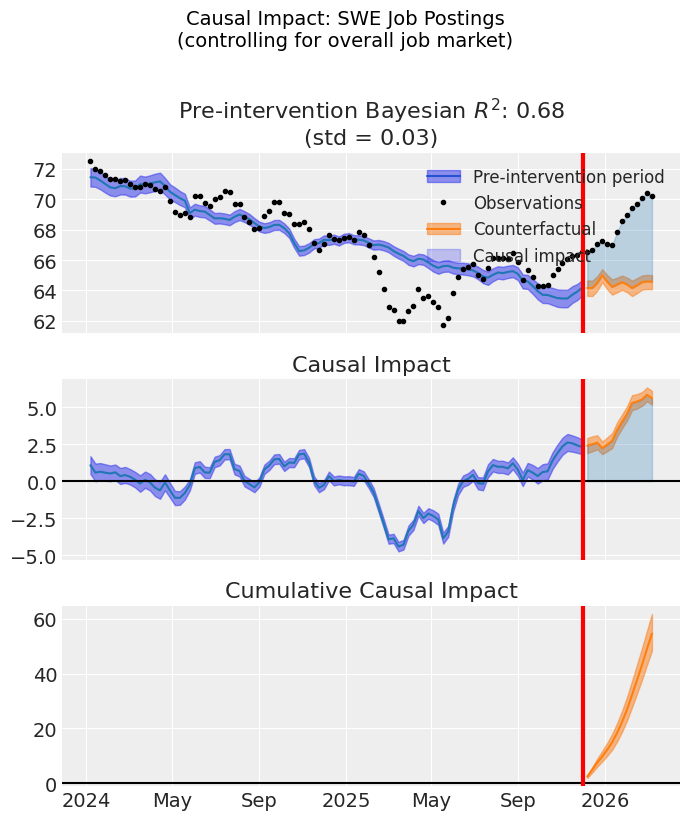

In [ ]:
import matplotlib.pyplot as plt
fig_causal, axes = result.plot()
fig_causal.suptitle(
    "Causal Impact: SWE Job Postings\n(controlling for overall job market)",
    y=1.02,
    fontsize=14,
)
fig_causal.tight_layout()
plt.close(fig_causal)  # prevent double render
fig_causal

In [ ]:
_summary = result.summary() or ""
mo.md(f"```\n{_summary}\n```")

==================================Pre-Post Fit==================================
Formula: swe ~ 1 + overall
Model coefficients:
    Intercept    21, 94% HDI [15, 27]
    overall      0.42, 94% HDI [0.36, 0.47]
    y_hat_sigma  1.6, 94% HDI [1.4, 1.8]


```

```

### Sensitivity Analysis Ideas

The comment on LinkedIn raised good points:

1. **"All postings" includes SWE** — the comparison group is contaminated.
   A cleaner control would exclude software-related occupations.

2. **Negative control group** — compare against a sector with no plausible AI exposure
   (e.g., healthcare technicians, skilled trades) to validate the method.

3. **Additional FRED series to try:**
   - `IHLIDXUSTPNURSING` (Nursing)
   - `IHLIDXUSTPMECHANIC` (Mechanics)
   - `IHLIDXUSTPBANKING` (Banking & Finance)

These could serve as better comparison groups for a proper diff-in-diff.

---
*Data: Indeed via FRED | Analysis: PyMC Labs*